# Tutorials

Worked examples with live outputs. All geometry is in millimetres; sections
are returned as [`sectionproperties`](https://sectionproperties.readthedocs.io)
`Geometry` objects ready for meshing, analysis, `concreteproperties` or
`ospgrillage`.



## Irish Y beam: profile and strand map

The Y family carries the manufacturer's "all possible strand locations" map —
useful for laying out prestressing in design or assessment models.



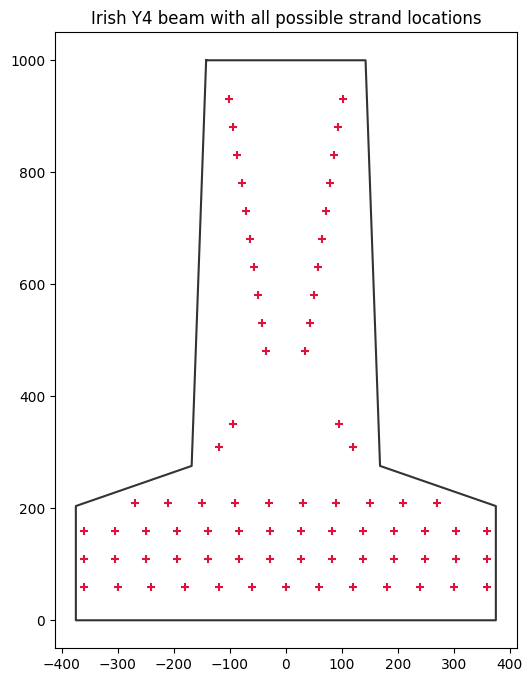

In [1]:
import matplotlib.pyplot as plt
from bridgebeams.ukie import IeYBeamSection, strand_locations

beam = IeYBeamSection("Y4")
strands = strand_locations("Y4")

fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(*beam.polygon.exterior.xy, color="0.2", lw=1.5)
ax.scatter([p[0] for p in strands], [p[1] for p in strands], marker="+", color="crimson", s=30)
ax.set_aspect("equal")
ax.set_title("Irish Y4 beam with all possible strand locations")
plt.show()

## Live validation against the manufacturer's tables

The suite checks every family against the manufacturers' published section
properties. Here for a single beam, computed exactly from the reconstructed
profile vs the published Y4 row (Banagher *Bridge Beam Manual*, 3rd ed.):



In [2]:
from bridgebeams._geometry import section_properties

props = section_properties(beam.polygon)
pub = beam.published

print(f"{'':8s}{'computed':>12s}{'published':>12s}")
print(f"{'A [mm2]':8s}{props['area']:12.0f}{pub['area']:12.0f}")
print(f"{'yc [mm]':8s}{props['cy']:12.1f}{pub['yc']:12.1f}")
print(f"{'Ixx[e9]':8s}{props['ixx']/1e9:12.3f}{pub['ixx_e9']:12.3f}")

            computed   published
A [mm2]       416846      410880
yc [mm]        398.1       399.3
Ixx[e9]       36.669      38.220


## TY beams: beam & slab vs solid slab variants

The TY family comes in two deck contexts: a nibbed top for beam & slab
decks, and a full top flange for solid slab decks. Same designation, different
geometry — keyed by `variant`.



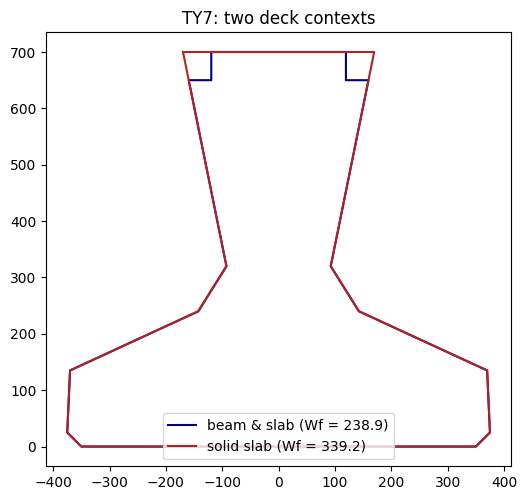

In [3]:
from bridgebeams.ukie import IeTYBeamSection

ty7_bs = IeTYBeamSection("TY7", variant="bs")
ty7_ss = IeTYBeamSection("TY7", variant="ss")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(*ty7_bs.polygon.exterior.xy, color="navy", lw=1.5, label="beam & slab (Wf = 238.9)")
ax.plot(*ty7_ss.polygon.exterior.xy, color="firebrick", lw=1.5, label="solid slab (Wf = 339.2)")
ax.set_aspect("equal")
ax.legend()
ax.set_title("TY7: two deck contexts")
plt.show()

## U beams: published top dimensions

U beams publish `W1`/`W2`/`W3` per size; the profile recovers the published
properties to within 0.3% across the whole range including the SU edge
beams.



U8: depth 1200 mm, W1 = 1286.4, W2 = 642.0, W3 = 242.2


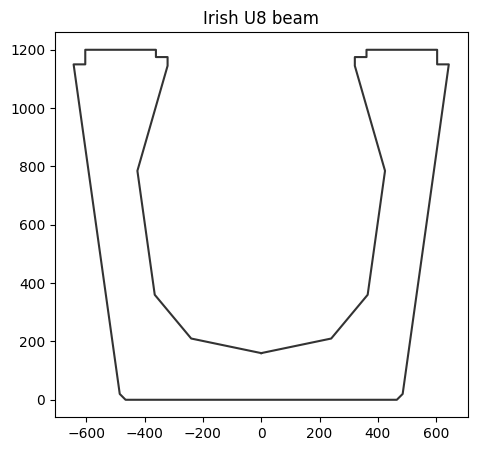

In [4]:
from bridgebeams.ukie import IeUBeamSection

u8 = IeUBeamSection("U8")
print(f"U8: depth {u8.dimensions.depth:.0f} mm, "
      f"W1 = {u8.dimensions.w1:.1f}, W2 = {u8.dimensions.w2:.1f}, W3 = {u8.dimensions.w3:.1f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(*u8.polygon.exterior.xy, color="0.2", lw=1.5)
ax.set_aspect("equal")
ax.set_title("Irish U8 beam")
plt.show()

## Section properties for ospgrillage

`ospgrillage` works with section *properties* rather than geometry — the
adapter runs a `sectionproperties` analysis and returns the dict that
`og.create_section` expects.



In [5]:
from bridgebeams import osp_grillage_properties
from bridgebeams.ukie import IeSYBeamSection

sy4 = IeSYBeamSection("SY4")
props = osp_grillage_properties(sy4.geometry)
for k, v in props.items():
    print(f"{k}: {v:.6g}")

A: 646132
J: 1.94851e+10
Iy: 1.32418e+10
Iz: 2.08923e+11
Ay: 646132
Az: 646132


## With concreteproperties

Wrapping a beam with a `concreteproperties` material gives the full
`ConcreteSection` API for design checks:



In [6]:
from concreteproperties.material import Concrete
from concreteproperties.stress_strain_profile import ConcreteLinear, ConcreteUltimateProfile
from bridgebeams import to_concreteproperties

concrete = Concrete(
    name="50 MPa",
    density=2.4e-6,
    stress_strain_profile=ConcreteLinear(elastic_modulus=34e3),
    ultimate_stress_strain_profile=ConcreteUltimateProfile(
        strains=[0.0, 0.003], stresses=[0.0, 50.0], compressive_strength=50
    ),
    flexural_tensile_strength=4.2,
    colour="lightgrey",
)

cs = to_concreteproperties(beam.geometry, concrete)
print(f"Gross concrete area: {cs.gross_properties.concrete_area:,.0f} mm2")
print(f"Centroid: ({cs.gross_properties.cx_gross:.1f}, {cs.gross_properties.cy_gross:.1f}) mm")

Gross concrete area: 416,846 mm2
Centroid: (-0.0, 398.1) mm
